# Task 2 — Technical indicators (TA-Lib + PyNance)

Loads the OHLCV extract, enforces dtypes, handles missing rows, then computes **SMA**, **EMA**, **RSI**, and **MACD** with TA-Lib. PyNance `tech.simple.ret` provides a cross-check for simple returns used in risk-style metrics.


In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import talib

try:
    import pynance.tech.simple as pnts
    PYNANCE_OK = True
except Exception as _pn_err:
    print(f"PyNance import skipped ({_pn_err.__class__.__name__}): falling back to pandas pct_change.")
    PYNANCE_OK = False

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 8)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

prices = pd.read_csv(ROOT / "data" / "raw" / "stock_prices_sample.csv")
prices.head()


PyNance import skipped (TypeError): falling back to pandas pct_change.


,Date,stock,Open,High,Low,Close,Adj Close,Volume
0,2023-01-03,AAPL,282.3910,283.0209,281.1706,281.9575,281.9575,40952895
1,2023-01-04,AAPL,281.9575,284.9925,281.4189,283.1226,283.1226,1824471
2,2023-01-05,AAPL,283.1226,287.8614,281.5719,286.5154,286.5154,34279858
3,2023-01-06,AAPL,286.5154,287.8433,285.6253,286.9491,286.9491,42289812
4,2023-01-09,AAPL,286.9491,287.9663,282.3321,284.1551,284.1551,48415313


## Choose a ticker and clean the panel


In [2]:
SYMBOL = "AAPL"
df = prices.loc[prices["stock"] == SYMBOL].copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

num_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before = len(df)
df = df.dropna(subset=["Adj Close", "Close"])
print(f"Dropped {before - len(df)} rows missing core price fields")

# Basic sanity: no negative prices
assert (df["Adj Close"] > 0).all()

df[num_cols].describe()


Dropped 0 rows missing core price fields


,Open,High,Low,Close,Adj Close,Volume
count,320.000000,320.000000,320.000000,320.000000,320.000000,3.200000e+02
mean,335.032459,338.587150,331.807810,335.438809,335.438809,2.557602e+07
std,26.746033,27.225334,26.373873,26.930892,26.930892,1.434092e+07
min,279.955700,281.716800,277.508100,279.955700,279.955700,1.092585e+06
25%,315.371225,319.296225,312.553450,315.505850,315.505850,1.213131e+07
50%,336.647450,339.130800,334.606250,336.720250,336.720250,2.703843e+07
75%,356.290025,359.227575,350.695275,356.377250,356.377250,3.817379e+07
max,422.513200,425.281600,420.172000,422.513200,422.513200,4.998603e+07


## TA-Lib indicators


In [3]:
close = df["Adj Close"].astype(float)
high = df["High"].astype(float)
low = df["Low"].astype(float)

df["SMA_20"] = talib.SMA(close, timeperiod=20)
df["SMA_50"] = talib.SMA(close, timeperiod=50)
df["EMA_20"] = talib.EMA(close, timeperiod=20)

df["RSI_14"] = talib.RSI(close, timeperiod=14)

macd, macd_signal, macd_hist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
df["MACD"] = macd
df["MACD_signal"] = macd_signal
df["MACD_hist"] = macd_hist

df["pct_change_close"] = df["Adj Close"].pct_change()

if PYNANCE_OK:
    pn_returns = pnts.ret(df[["Adj Close"]], selection="Adj Close", n_sessions=1)
    df["pn_return"] = pn_returns.reindex(df.index)["Return"]
    print("Mean abs diff PyNance vs pandas pct_change:", (df["pn_return"] - df["pct_change_close"]).abs().mean())
else:
    df["pn_return"] = df["pct_change_close"]
    print("PyNance unavailable — pn_return set to pandas pct_change (same computation).")

print(df[["Adj Close", "SMA_20", "SMA_50", "EMA_20", "RSI_14", "MACD", "pct_change_close"]].tail())


PyNance unavailable — pn_return set to pandas pct_change (same computation).
            Adj Close      SMA_20      SMA_50      EMA_20     RSI_14  \
Date                                                                   
2024-03-19   405.9761  371.342605  364.271160  375.308347  70.273746   
2024-03-20   421.4346  373.703980  366.009198  379.701324  74.925436   
2024-03-21   422.5132  375.998400  367.730824  383.778645  75.216846   
2024-03-22   412.7693  378.690290  369.247338  386.539660  67.576323   
2024-03-25   412.4230  381.770920  370.663796  389.004740  67.314612   

                 MACD  pct_change_close  
Date                                     
2024-03-19   7.902269          0.018057  
2024-03-20  10.582192          0.038077  
2024-03-21  12.647294          0.002559  
2024-03-22  13.343832         -0.023062  
2024-03-25  13.709861         -0.000839  


## Visual diagnostics


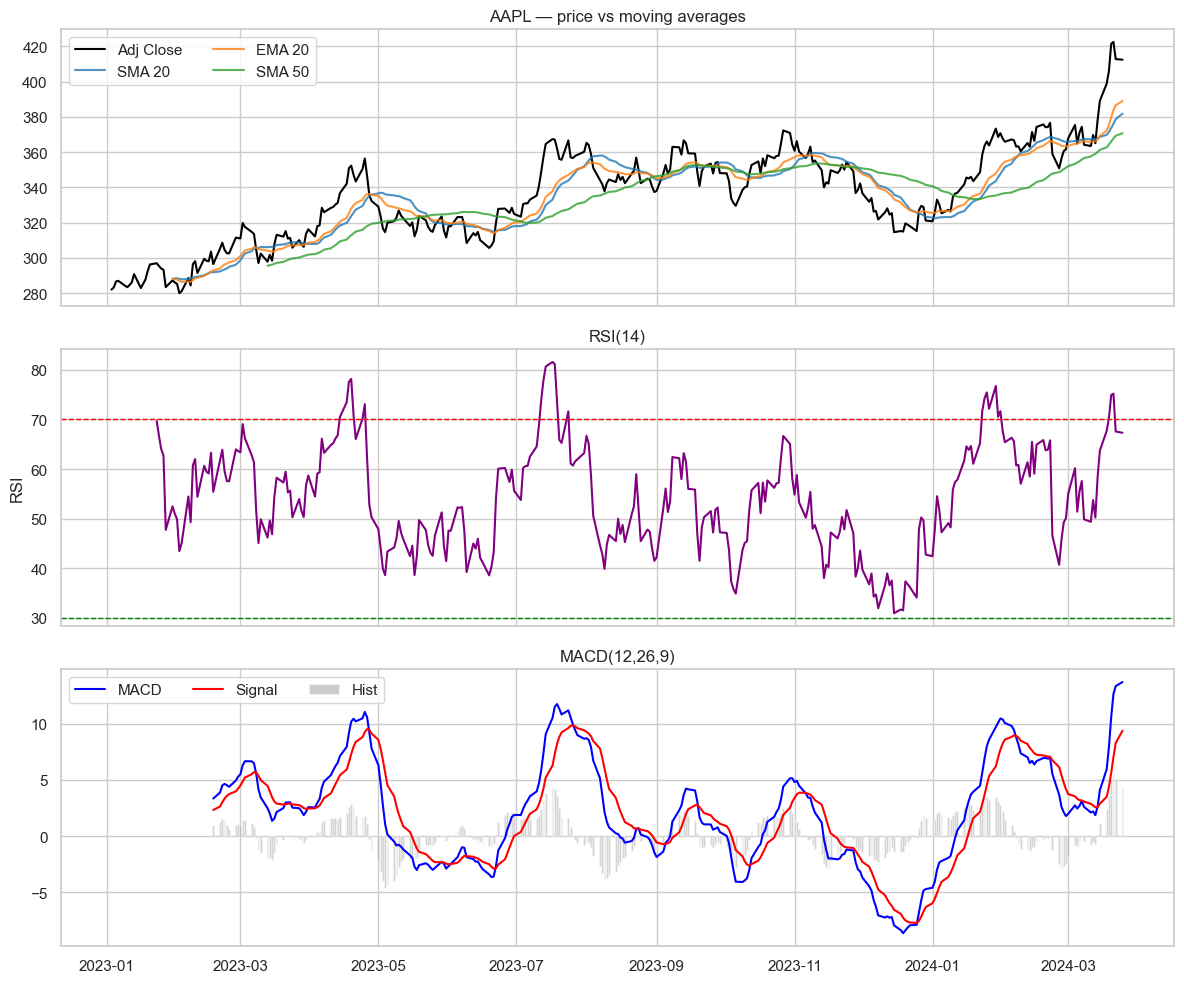

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df.index, df["Adj Close"], label="Adj Close", color="black")
axes[0].plot(df.index, df["SMA_20"], label="SMA 20", color="tab:blue", alpha=0.8)
axes[0].plot(df.index, df["EMA_20"], label="EMA 20", color="tab:orange", alpha=0.8)
axes[0].plot(df.index, df["SMA_50"], label="SMA 50", color="tab:green", alpha=0.8)
axes[0].set_title(f"{SYMBOL} — price vs moving averages")
axes[0].legend(loc="upper left", ncol=2)

axes[1].plot(df.index, df["RSI_14"], color="purple")
axes[1].axhline(70, color="red", ls="--", lw=1)
axes[1].axhline(30, color="green", ls="--", lw=1)
axes[1].set_title("RSI(14)")
axes[1].set_ylabel("RSI")

axes[2].plot(df.index, df["MACD"], label="MACD", color="blue")
axes[2].plot(df.index, df["MACD_signal"], label="Signal", color="red")
axes[2].bar(df.index, df["MACD_hist"], label="Hist", color="gray", alpha=0.4)
axes[2].set_title("MACD(12,26,9)")
axes[2].legend(loc="upper left", ncol=3)

plt.tight_layout()
plt.show()


## Data prep notes (for the interim / final report)

- **Adjusted closes** feed return math and MACD/RSI so corporate actions do not spuriously shift momentum signals.
- **Warm-up rows**: SMA/EMA/MACD need initial windows; drop leading `NaN`s before exporting features to ML.
- **Quality issues spotted**: verify duplicate calendar rows per symbol, split-adjustment consistency, and outliers (bad prints). This sample is synthetic — rehearse the same checks on YFinance pulls.
